In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
# import matplotlib
# matplotlib.use('TkAgg') # Sử dụng backend Tkinter để hiển thị cửa sổ
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler, MinMaxScaler

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)

# HOMEWORK

## Bài 1: Titanic Dataset

Sử dụng lại bộ dữ liệu **Titanic** trong bài tập về nhà trước.

### Yêu cầu

1. Sử dụng **Logistic Regression** để dự đoán hành khách sống sót hay không.
2. Sử dụng cùng cách chia dữ liệu train/test như bài tập trước nếu có thể.
3. Đánh giá kết quả của mô hình Logistic Regression.
4. So sánh kết quả của **Logistic Regression** với kết quả của **Linear Regression** trong bài tập trước.

### Nội dung so sánh

Có thể so sánh dựa trên các chỉ số:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

Đưa ra nhận xét về mô hình phù hợp hơn đối với bài toán phân loại hành khách sống sót.



In [2]:
try:
    df = sns.load_dataset("titanic")
    print("Đã tải từ seaborn.")
except Exception:
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df = pd.read_csv(url)
    df.columns = [c.lower() for c in df.columns]
    print("Đã tải từ URL.")

Đã tải từ seaborn.


In [3]:
# bỏ các cột rò rỉ/dư thừa, gán lại vào biến df
leaky = ['alive', 'who', 'adult_male', 'class', 'deck', 'embark_town', 'alone']
df = df.drop(columns=leaky)

# chia train/val/test có stratify
X = df.drop(columns=["survived"])
y = df["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Tỷ lệ survived từng tập")
print("Train:", y_train.mean().round(3))
# print("Val:", y_val.mean().round(3))
print("Test:", y_test.mean().round(3))


num_cols = ["age", "sibsp", "parch", "fare"]
cat_cols = ["sex", "embarked"]
ord_cols = ["pclass"]

Tỷ lệ survived từng tập
Train: 0.383
Test: 0.385


In [4]:
# xây pipeline cho biến số và biến phân loại
pipe_so  = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  RobustScaler()),
])
pipe_cat = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    # ignore: bỏ qua giá trị lạ và không báo lỗi(toàn bộ các cột One-Hot tương ứng với hàng dữ liệu đó sẽ được điền số 0.)
    # sparse_output: (Định dạng dữ liệu đầu ra)
    # Nếu True (Mặc định): Quá trình One-Hot sinh ra cực kỳ nhiều số 0 (ví dụ: cột có 100 hạng mục sẽ sinh ra 99 số 0 và chỉ 1 số 1 cho mỗi hàng). Để tiết kiệm bộ nhớ RAM, thư viện sẽ nén nó thành Sparse Matrix (Ma trận thưa) — một dạng cấu trúc chỉ lưu trữ "vị trí" của các số 1.
    # Khi dùng False: Thuật toán sẽ trả về một mảng Numpy 2 chiều thông thường (Dense Array), hiển thị đầy đủ và rõ ràng từng số 0 và 1.
])

preprocess = ColumnTransformer([
    ("num", pipe_so,  num_cols),
    ("cat", pipe_cat, cat_cols),
    ("ord", "passthrough", ord_cols),
])

preprocess.fit(X_train)               # fit CHỈ trên train

X_train_t = preprocess.transform(X_train)
# X_val_t = preprocess.transform(X_val)
X_test_t = preprocess.transform(X_test)



In [5]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def compute_loss(y_true, y_pred):
    # tính loss binary cross-entropy
    epsilon = 1e-15  # để tránh log(0)
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)  # giới hạn giá trị dự đoán
    loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    return loss

y_train_np = y_train.to_numpy()[:, np.newaxis]  # chuyển sang dạng cột
# y_val_np = y_val.to_numpy()[:, np.newaxis]  # chuyển sang dạng cột
y_test_np = y_test.values.reshape(-1, 1)
# 1. Khởi tạo tham số
m_train, n_features = X_train_t.shape
w = np.zeros((n_features, 1))  # trọng số ban đầu
b = 0.0  # bias ban đầu

learning_rate = 0.05
epochs = 5000

train_losses = []
# val_losses = []

for epoch in range(epochs):
    # 2. Tính dự đoán
    z_train = np.dot(X_train_t, w) + b
    y_train_pred = sigmoid(z_train)

    # z_val = np.dot(X_val_t, w) + b
    # y_val_pred = sigmoid(z_val)

    # 3. Tính loss
    train_loss = compute_loss(y_train_np, y_train_pred)
    # val_loss = compute_loss(y_val_np, y_val_pred)

    train_losses.append(train_loss)
    # val_losses.append(val_loss)

    # 4. Tính gradient
    dz_train = y_train_pred - y_train_np
    dw = np.dot(X_train_t.T, dz_train) / m_train
    db = np.sum(dz_train) / m_train

    # 5. Cập nhật tham số
    w -= learning_rate * dw
    b -= learning_rate * db

    # # --- VALIDATION ---
    # # Tính Loss trên tập Val để vẽ biểu đồ (không cập nhật w, b bằng tập Val)
    # Z_val = np.dot(X_val_t, w) + b
    # A_val = sigmoid(Z_val)
    # val_loss = compute_loss(y_val_np, A_val)
    # val_losses.append(val_loss)

    if epoch % 200 == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch:4d} | Train Loss: {train_loss:.4f}") #  | Val Loss: {val_loss:.4f}

print("Huấn luyện hoàn tất!")


Epoch    0 | Train Loss: 0.6931
Epoch  200 | Train Loss: 0.4841
Epoch  400 | Train Loss: 0.4615
Epoch  600 | Train Loss: 0.4535
Epoch  800 | Train Loss: 0.4493
Epoch 1000 | Train Loss: 0.4465
Epoch 1200 | Train Loss: 0.4444
Epoch 1400 | Train Loss: 0.4428
Epoch 1600 | Train Loss: 0.4415
Epoch 1800 | Train Loss: 0.4405
Epoch 2000 | Train Loss: 0.4397
Epoch 2200 | Train Loss: 0.4391
Epoch 2400 | Train Loss: 0.4385
Epoch 2600 | Train Loss: 0.4381
Epoch 2800 | Train Loss: 0.4378
Epoch 3000 | Train Loss: 0.4375
Epoch 3200 | Train Loss: 0.4372
Epoch 3400 | Train Loss: 0.4371
Epoch 3600 | Train Loss: 0.4369
Epoch 3800 | Train Loss: 0.4368
Epoch 4000 | Train Loss: 0.4367
Epoch 4200 | Train Loss: 0.4366
Epoch 4400 | Train Loss: 0.4365
Epoch 4600 | Train Loss: 0.4364
Epoch 4800 | Train Loss: 0.4364
Epoch 4999 | Train Loss: 0.4363
Huấn luyện hoàn tất!


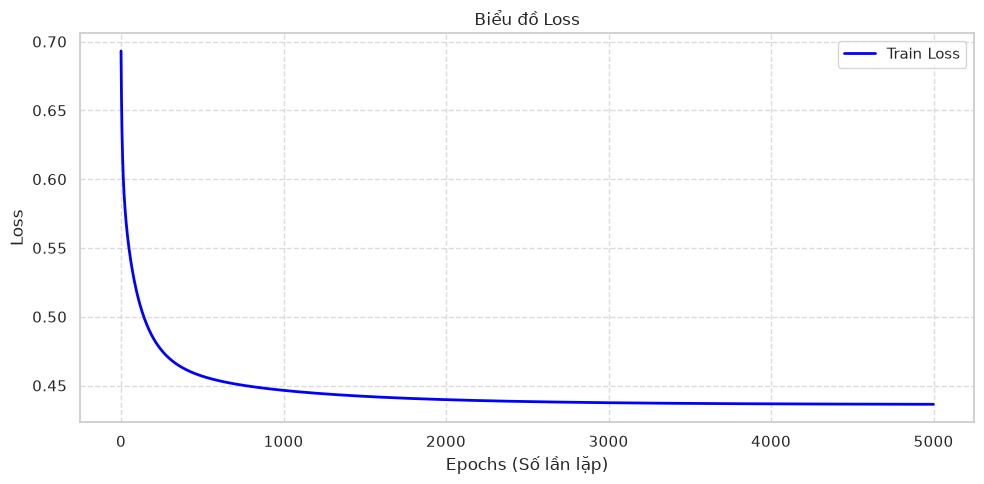

--- KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST ---
Số lượng mẫu dự đoán đúng: 144 / 179
Độ chính xác (Accuracy)  : 80.45%
Precision                 : 79.31%
Recall                    : 66.67%
F1-score                  : 72.44%
--------------------------------------
Confusion Matrix:
[[98 12]
 [23 46]]


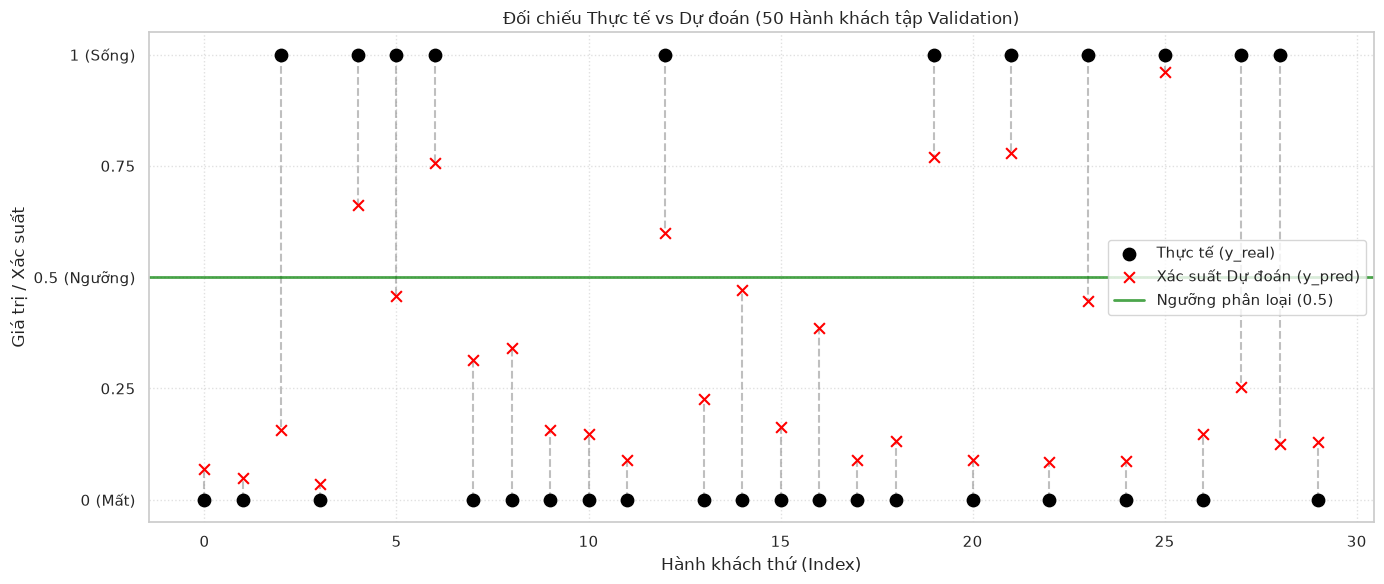

In [6]:
# 3. Vẽ trực quan hóa quá trình Loss cắm đầu xuống
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', color='blue', linewidth=2)
# plt.plot(val_losses, label='Validation Loss', color='orange', linewidth=2)

plt.title('Biểu đồ Loss')
plt.xlabel('Epochs (Số lần lặp)')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



# 1. Chuẩn bị định dạng y_test (chuyển thành vector cột để khớp kích thước)
y_test_np = y_test.values.reshape(-1, 1)

# 2. Lan truyền tiến (Forward) trên tập Test bằng w và b hội tụ mới nhất
Z_test = np.dot(X_test_t, w) + b
A_test = sigmoid(Z_test)  # Đây là y_pred ở dạng xác suất (0 đến 1)

# 3. Phân loại bằng ngưỡng (Threshold = 0.5)
# Nếu xác suất >= 0.5 sẽ trả về True (1), ngược lại trả về False (0)

y_pred_labels = (A_test >= 0.5).astype(int)

# 4. Tính toán các chỉ số đánh giá
correct_predictions = np.sum(y_pred_labels == y_test_np)
total_samples = y_test_np.shape[0]
accuracy = correct_predictions / total_samples

# Tính Precision, Recall, F1-score và Confusion Matrix
precision = precision_score(y_test_np, y_pred_labels)
recall = recall_score(y_test_np, y_pred_labels)
f1 = f1_score(y_test_np, y_pred_labels)
cm = confusion_matrix(y_test_np, y_pred_labels)

# 5. In kết quả đánh giá tổng hợp
print("--- KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST ---")
print(f"Số lượng mẫu dự đoán đúng: {correct_predictions} / {total_samples}")
print(f"Độ chính xác (Accuracy)  : {accuracy * 100:.2f}%")
print(f"Precision                 : {precision * 100:.2f}%")
print(f"Recall                    : {recall * 100:.2f}%")
print(f"F1-score                  : {f1 * 100:.2f}%")
print("-" * 38)
print("Confusion Matrix:")
print(cm)


samples = 30 # Chỉ lấy 30 người đầu tiên để đồ thị thoáng mắt
x_axis = np.arange(samples)

plt.figure(figsize=(14, 6))

# 1. Vẽ các điểm Thực tế (y_real) - Chỉ nằm ở mức 0 hoặc 1
plt.scatter(x_axis, y_test_np[:samples], color='black', s=80, label='Thực tế (y_real)', marker='o', zorder=3)

# 2. Vẽ các điểm Dự đoán (y_pred) - Nằm rải rác từ 0 đến 1
plt.scatter(x_axis, A_test[:samples], color='red', s=60, label='Xác suất Dự đoán (y_pred)', marker='x', zorder=3)

# 3. Vẽ đường nối để thấy mô hình kéo xác suất về gần thực tế như thế nào
for i in range(samples):
    plt.plot([i, i], [y_test_np[i][0], A_test[i][0]], color='gray', linestyle='--', alpha=0.5)

# 4. Vẽ đường ranh giới sinh tử (Ngưỡng 0.5)
plt.axhline(0.5, color='green', linestyle='-', linewidth=2, alpha=0.7, label='Ngưỡng phân loại (0.5)')

plt.title('Đối chiếu Thực tế vs Dự đoán (50 Hành khách tập Validation)')
plt.xlabel('Hành khách thứ (Index)')
plt.ylabel('Giá trị / Xác suất')
plt.yticks([0, 0.25, 0.5, 0.75, 1], ['0 (Mất)', '0.25', '0.5 (Ngưỡng)', '0.75', '1 (Sống)'])
plt.legend(loc='center right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

### 3. Đánh giá kết quả của mô hình Logistic Regression.

+ Độ chính xác (Accuracy) đạt 80.45% trên tập test (dự đoán đúng 144/179 mẫu). Đây là một hiệu suất khá tốt đối với bộ dữ liệu Titanic.

+ Hội tụ của mô hình (Loss curve): Đồ thị Loss giảm mạnh ở các epochs đầu và hội tụ ổn định sau khoảng 2000 epochs. Điều này cho thấy thuật toán tối ưu đã hoạt động tốt, mô hình học được đặc trưng từ dữ liệu. Tuy nhiên, Loss hội tụ ở mức 0.44 vì dữ liệu không thể phân tách tuyến tính hoàn toàn do chứa nhiễu, nên đây là giới hạn tối ưu để mô hình khái quát hóa tốt mà không bị "học vẹt" (overfitting).

+ Chi tiết phân loại: Biểu đồ đối chiếu cho thấy ngưỡng phân loại (threshold) được đặt ở mức 0.5. Đa số các mẫu thực tế "0" (Mất) có dự đoán dưới ngưỡng và thực tế "1" (Sống) có dự đoán trên ngưỡng. Tuy nhiên, vẫn tồn tại một số sai số (False Positives và False Negatives) khi có các điểm dấu x đỏ nằm sai phía so với đường ranh giới màu xanh.

### 4. So sánh kết quả của **Logistic Regression** với kết quả của **Linear Regression** trong bài tập trước.

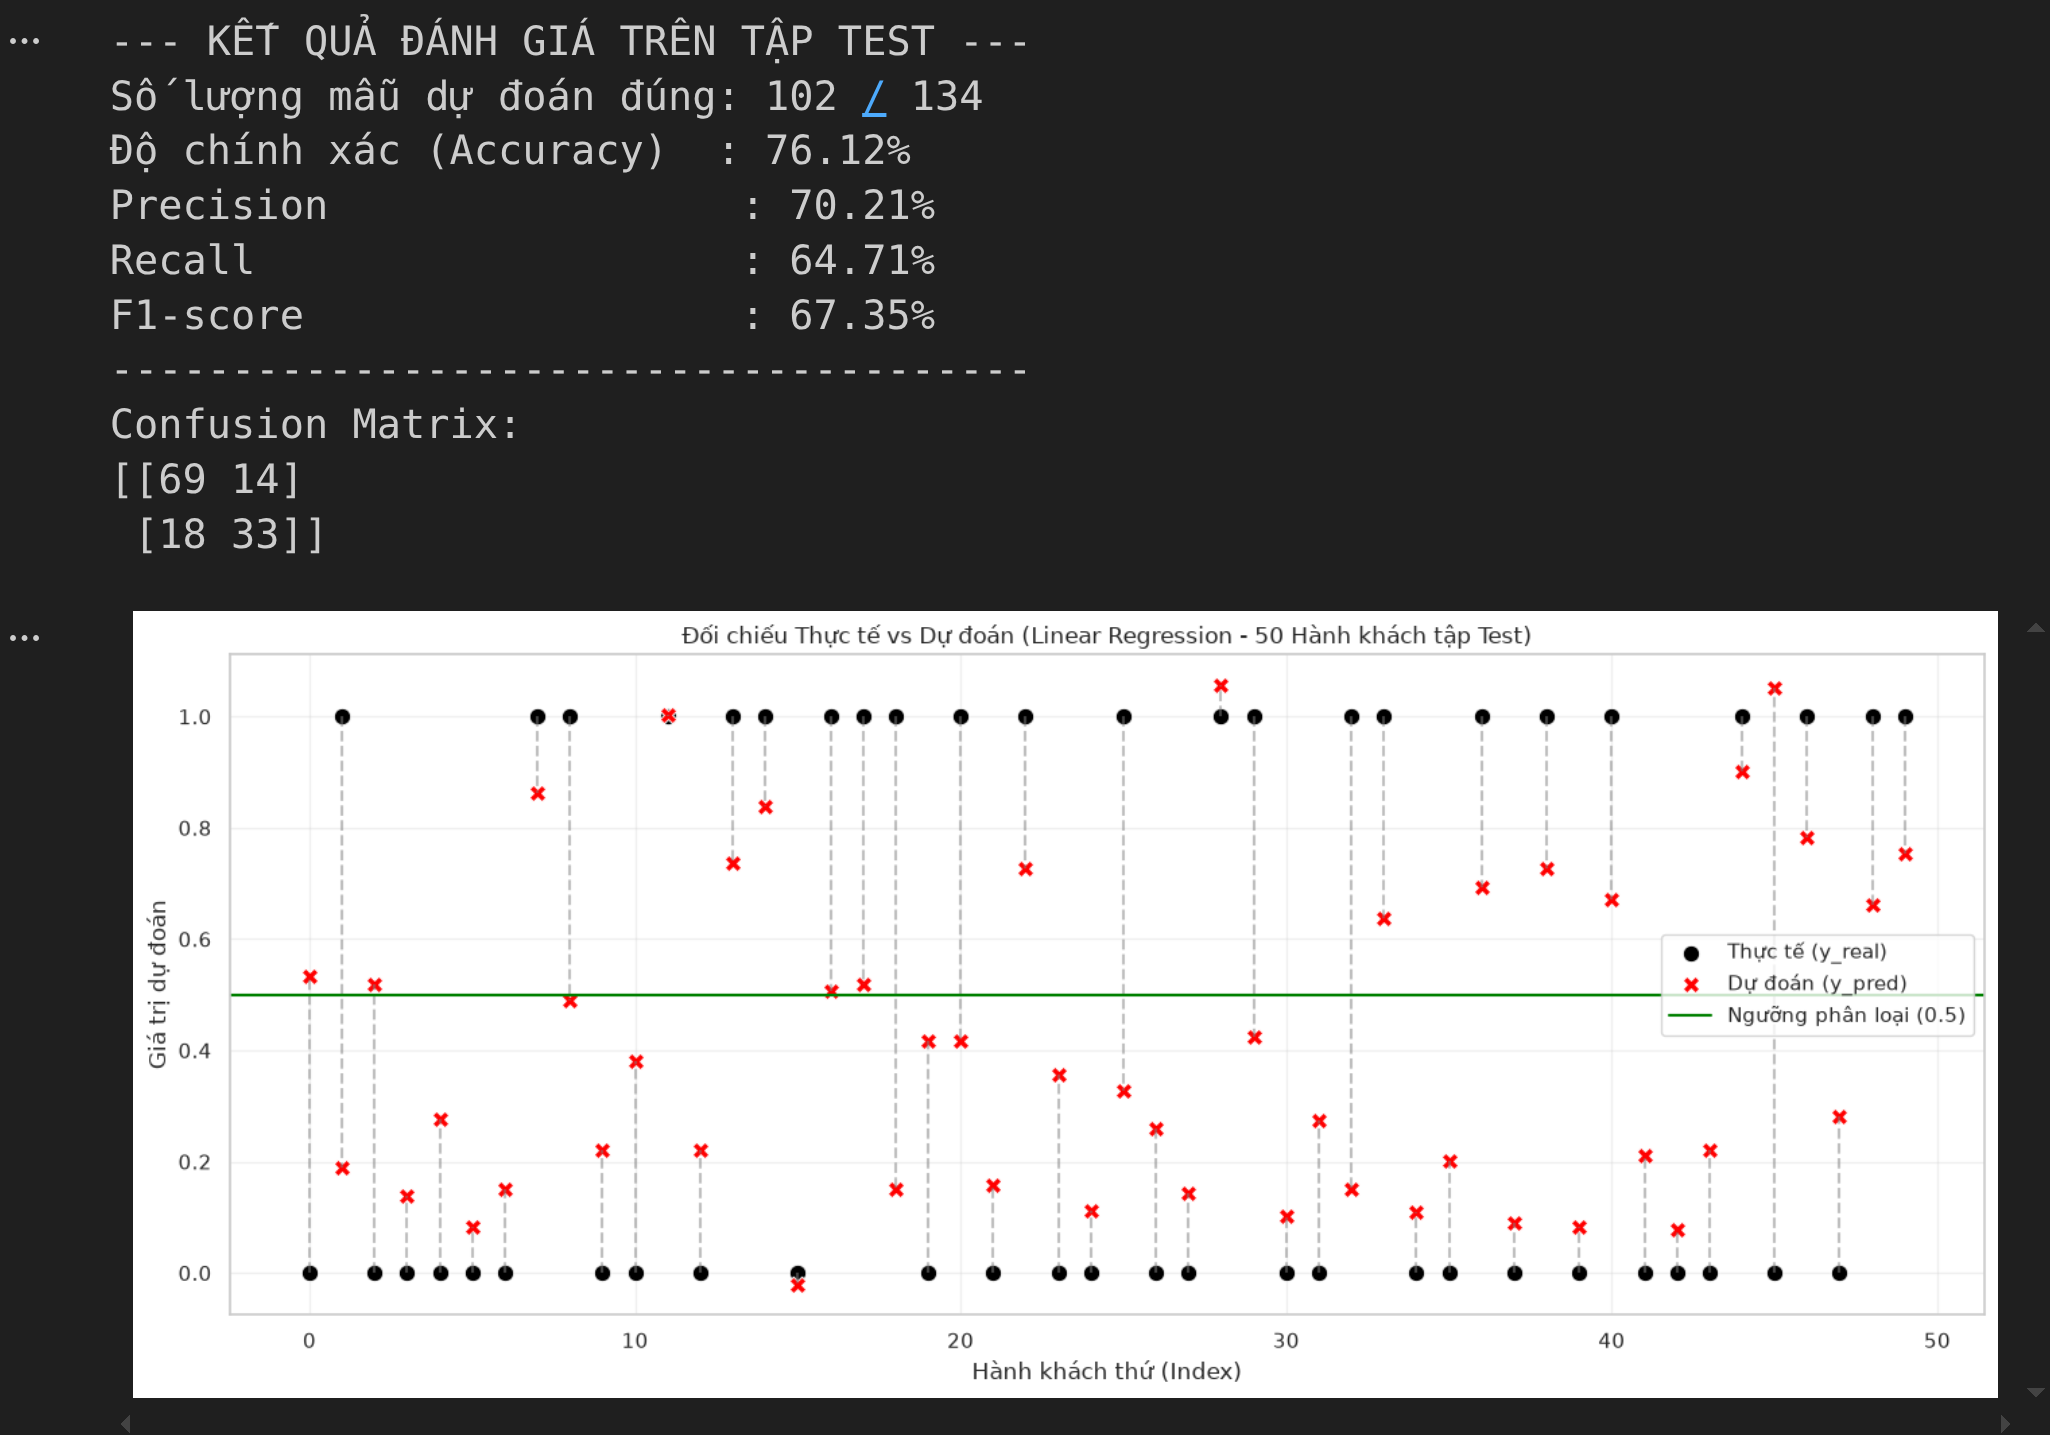

| Chỉ số đánh giá | Logistic Regression | Linear Regression | Nhận xét |
| :--- | :---: | :---: | :--- |
| **Accuracy** | 80.45% | 76.12% | Logistic Regression cao hơn ~4.3% |
| **Precision** | 79.31% | 70.21% | Logistic Regression vượt trội hơn ~9.1% |
| **Recall** | 66.67% | 64.71% | Logistic Regression nhỉnh hơn ~2.0% |
| **F1-score** | 72.44% | 67.35% | Logistic Regression cao hơn ~5.1% |

**Phân tích Confusion Matrix:**
*   **Logistic Regression:** Kiểm soát khá tốt tỷ lệ dự đoán sai (chỉ có 12 False Positive và 23 False Negative trên tổng số 179 mẫu).
*   **Linear Regression:** Tỷ lệ bắt sai (False Positive) và bỏ lọt (False Negative) chiếm tỷ trọng lớn hơn đáng kể trong tổng số dự đoán.

**Kết luận chung:**
Mô hình **Logistic Regression phù hợp và tốt hơn hoàn toàn** đối với bài toán phân loại hành khách sống sót (bài toán phân loại nhị phân).


---

## Bài 2: Dry Bean Dataset

Xây dựng mô hình phân loại các loại hạt trong bộ dữ liệu **Dry Bean Dataset** bằng hai thuật toán:

1. **Logistic Regression**
2. **K-Nearest Neighbors – KNN**

### Dữ liệu

Dữ liệu đã được preprocessing (file processing_seeds.ipynb) và chia thành hai tập:

```text
Dry_Bean_Dataset/
├── dry_bean_train.csv
└── dry_bean_test.csv

Các bạn có thể tự tạo file processing để có thể processing theo ý mình

In [7]:
# 1. ĐỌC VÀ CHUẨN BỊ DỮ LIỆU

DATA_CANDIDATES_TRAIN = [
    Path("week04/Homework_b7/Dry_Bean_Dataset/dry_bean_train.csv"),
    Path("Dry_Bean_Dataset/dry_bean_train.csv"),
    Path("../Dry_Bean_Dataset/dry_bean_train.csv"),
    Path("/content/dry_bean_train.csv")
]
DATA_PATH_TRAIN = next((path for path in DATA_CANDIDATES_TRAIN if path.exists()), None)
if DATA_PATH_TRAIN is None:
    raise FileNotFoundError("Không tìm thấy Dry_Bean_Dataset/dry_bean_train.csv")

DATA_CANDIDATES_TEST = [
    Path("week04/Homework_b7/Dry_Bean_Dataset/dry_bean_test.csv"),
    Path("Dry_Bean_Dataset/dry_bean_test.csv"),
    Path("../Dry_Bean_Dataset/dry_bean_test.csv"),
    Path("/content/dry_bean_test.csv")
]
DATA_PATH_TEST = next((path for path in DATA_CANDIDATES_TEST if path.exists()), None)
if DATA_PATH_TEST is None:
    raise FileNotFoundError("Không tìm thấy Dry_Bean_Dataset/dry_bean_test.csv")


print("Data path train:", DATA_PATH_TRAIN.resolve())
print("Data path test:", DATA_PATH_TEST.resolve())
train_df = pd.read_csv(DATA_PATH_TRAIN)
test_df = pd.read_csv(DATA_PATH_TEST)

Data path train: /media/quangnguyen/DATA/mliot-pyml-2026-hw/week04/Homework_b7/Dry_Bean_Dataset/dry_bean_train.csv
Data path test: /media/quangnguyen/DATA/mliot-pyml-2026-hw/week04/Homework_b7/Dry_Bean_Dataset/dry_bean_test.csv


In [8]:
target_col = 'class'
X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]

X_test = test_df.drop(columns=[target_col])
y_test = test_df[target_col]

print(f"Kích thước tập Train: {X_train.shape}")
print(f"Kích thước tập Test : {X_test.shape}\n")


Kích thước tập Train: (10834, 16)
Kích thước tập Test : (2709, 16)



In [9]:
# ==========================================
# 2. MÔ HÌNH LOGISTIC REGRESSION
# ==========================================

# 1. Khởi tạo Scaler
scaler = StandardScaler()

# 2. Fit và transform trên tập Train
X_train_scaled = scaler.fit_transform(X_train)

# 3. CHỈ transform trên tập Test (tuyệt đối không fit lại)
X_test_scaled = scaler.transform(X_test)

# 4. Huấn luyện mô hình với dữ liệu đã chuẩn hóa
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

# 5. Đừng quên dùng X_test_scaled khi dự đoán
y_pred_log = log_model.predict(X_test_scaled)

print("--- KẾT QUẢ LOGISTIC REGRESSION ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_log):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_log))



--- KẾT QUẢ LOGISTIC REGRESSION ---
Accuracy: 0.9192
Classification Report:
              precision    recall  f1-score   support

    BARBUNYA       0.93      0.89      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.91      0.94      0.93       326
    DERMASON       0.93      0.91      0.92       709
       HOROZ       0.96      0.94      0.95       372
       SEKER       0.93      0.94      0.94       406
        SIRA       0.86      0.88      0.87       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



In [10]:
# ==========================================
# 3. MÔ HÌNH K-NEAREST NEIGHBORS (KNN)
# ==========================================
# Khởi tạo KNN với số láng giềng k=5 (bạn có thể thay đổi để thử nghiệm)
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

print("\n--- KẾT QUẢ K-NEAREST NEIGHBORS (KNN) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_knn))


--- KẾT QUẢ K-NEAREST NEIGHBORS (KNN) ---
Accuracy: 0.7305
Classification Report:
              precision    recall  f1-score   support

    BARBUNYA       0.52      0.50      0.51       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.65      0.66      0.65       326
    DERMASON       0.81      0.90      0.85       709
       HOROZ       0.73      0.69      0.71       372
       SEKER       0.79      0.61      0.69       406
        SIRA       0.68      0.73      0.71       527

    accuracy                           0.73      2709
   macro avg       0.74      0.73      0.73      2709
weighted avg       0.73      0.73      0.73      2709



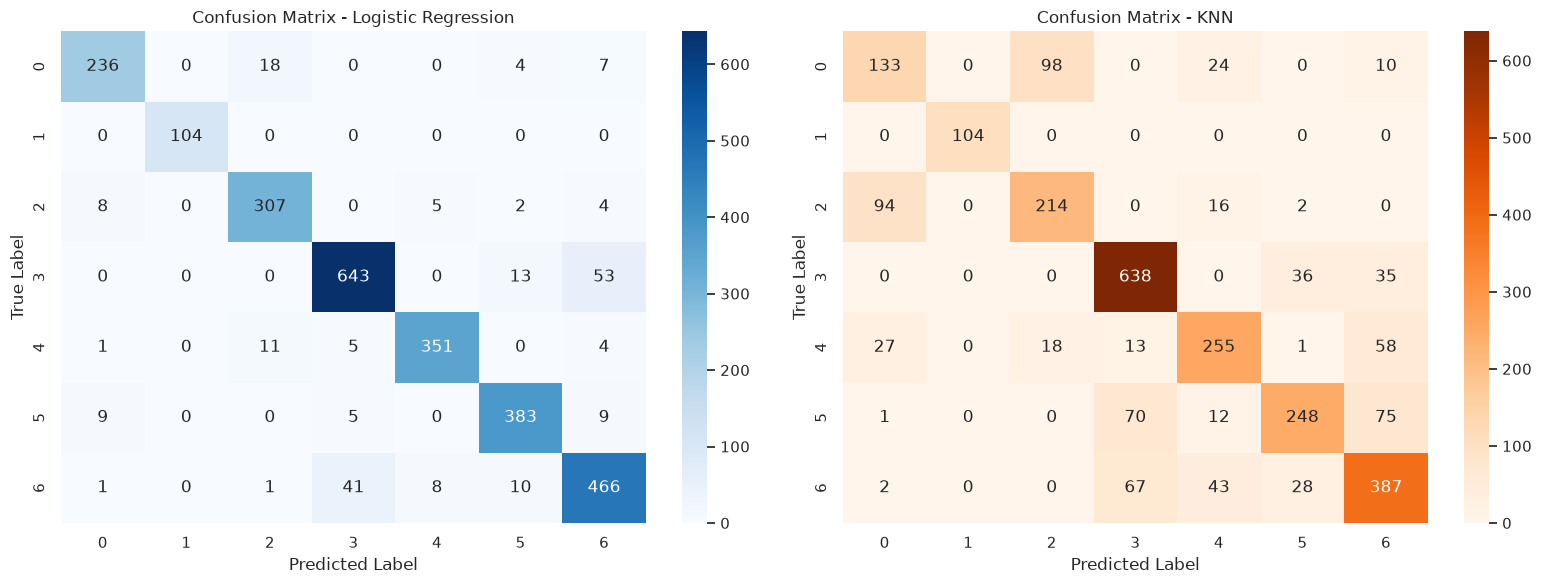

In [11]:
# ==========================================
# 4. TRỰC QUAN HÓA CONFUSION MATRIX (TÙY CHỌN)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix cho Logistic Regression
cm_log = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix - Logistic Regression')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Confusion Matrix cho KNN
cm_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Oranges', ax=axes[1])
axes[1].set_title('Confusion Matrix - KNN')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()